In [28]:
import pandas as pd
import seaborn as sns
import numpy as np

df = pd.read_csv('C:\\KDT\\train.csv')
df2 = pd.read_csv('C:\\KDT\\test.csv')

In [29]:
df = df.drop(columns=(['Name']))

df['GroupId'] = df['PassengerId'].str[:4]
count = df['GroupId'].value_counts()
df['GroupCount'] = df['GroupId'].map(count)

test_size = int(len(df) * 0.2)
index = np.random.permutation(len(df))

test_index = index[:test_size]
train_index = index[test_size:]
df_train = df.iloc[train_index]
df_test  = df.iloc[test_index]

x_train = df_train.drop(columns='Transported')
y_train = df_train['Transported']
x_test = df_test.drop(columns='Transported')
y_test = df_test['Transported']

In [30]:
df.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Transported', 'GroupId', 'GroupCount'],
      dtype='object')

클러스터링

<Axes: xlabel='RoomService', ylabel='FoodCourt'>

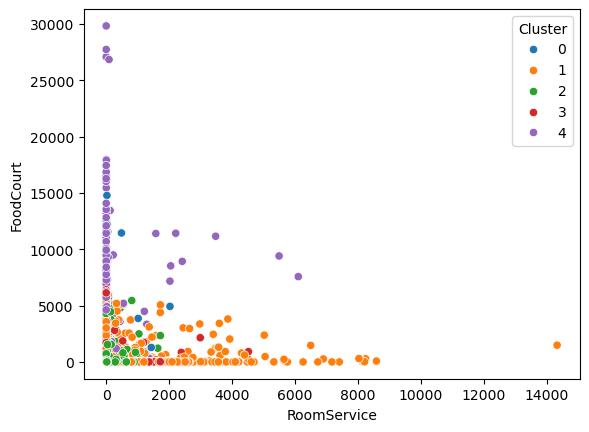

In [31]:
from sklearn.cluster import KMeans

num_col = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall',
           'Spa', 'VRDeck', 'GroupCount']

nums = x_train[num_col]
nums = nums.dropna(axis=0)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
nums2 = scaler.fit_transform(nums)
kmeans = KMeans(5)
kmeans.fit(nums2)
nums['Cluster'] = kmeans.predict(nums2)

import seaborn as sns
sns.scatterplot(nums, x='RoomService', y='FoodCourt', hue='Cluster',
                palette=sns.color_palette("tab10", n_colors=5))

In [36]:
nums.groupby('Cluster').mean()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,GroupCount
Cluster,,,,,,,
0,35.275591,73.937008,2018.031496,227.503937,841.039370,6469.370079,2.188976
1,44.179820,506.326945,369.836528,314.967306,217.964487,206.736753,1.600902
2,21.602950,107.936079,194.795943,129.927781,140.704364,130.898894,1.495083
3,19.562590,110.094964,260.917986,90.043165,145.877698,131.795683,5.607194
4,37.304933,165.704036,5517.538117,172.408072,4126.179372,658.721973,2.147982


In [37]:
nums2 = pd.concat([nums, y_train], join='inner', axis=1)
nums2.groupby('Cluster')['Transported'].mean()

Cluster
0    0.015748
1    0.459977
2    0.535648
3    0.618705
4    0.354260
Name: Transported, dtype: float64

차원축소

In [54]:
num_col = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall',
           'Spa', 'VRDeck', 'GroupCount']
nums = x_train[num_col]
nums = nums.dropna(axis=0)

In [55]:
from sklearn.manifold import TSNE
tsne = TSNE(init='pca', learning_rate='auto')
tsne.fit_transform(nums)

array([[ 47.526157,  49.31214 ],
       [-33.34998 ,  23.181915],
       [-11.201109,  46.940285],
       ...,
       [  9.159575,  17.71993 ],
       [-28.678099,  23.224035],
       [ 11.867287,  15.045192]], shape=(6073, 2), dtype=float32)

In [56]:
# 한 번만 실행
txy = _

<Axes: xlabel='tx', ylabel='ty'>

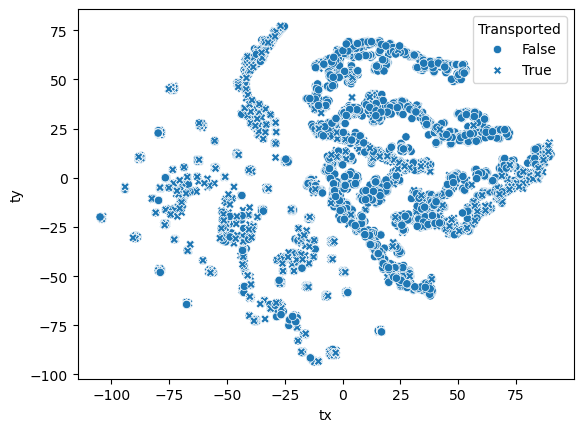

In [58]:
nums[['tx', 'ty']] = txy
nums2 = pd.concat([nums, y_train], axis=1)
sns.scatterplot(nums2, x='tx', y='ty', style='Transported')